In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
# 시각화 스타일 설정 : 배경 흰색, 파스텔톤

sns.set_style('white')

sns.set_palette('pastel')
# 한글 설정
plt.rcParams["font.family"] = 'Malgun Gothic'

plt.rcParams['axes.unicode_minus'] = False

In [44]:
df = pd.read_spss('data/Koweps_hpwc20_2025_beta1.sav')
df

,h20_id,h20_ind,h20_sn,h20_merkey,h_new,h_new1,h20_cobf,p20_wsc,p20_wsl,p20_wgc,...,wc20_63,wc20_64,wc20_5aq4,wc20_5aq5,wc20_5aq6,h20_pers_income1,h20_pers_income2,h20_pers_income3,h20_pers_income4,h20_pers_income5
0,2.0,1.0,1.0,20101.0,0.0,0.0,NaN,0.270248,0.269086,1513.433983,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
1,3.0,1.0,1.0,30101.0,0.0,0.0,NaN,0.424537,0.400322,2377.476553,...,NaN,NaN,NaN,NaN,NaN,NaN,2423.0,NaN,0.0,NaN
2,4.0,1.0,1.0,40101.0,0.0,0.0,NaN,0.230720,0.216585,1292.070254,...,NaN,NaN,NaN,NaN,NaN,NaN,337.0,NaN,0.0,NaN
3,6.0,1.0,1.0,60101.0,0.0,0.0,NaN,0.541744,0.498132,3033.853323,...,1.0,3.0,2.0,2.0,3.0,2825.0,NaN,NaN,0.0,NaN
4,6.0,1.0,1.0,60101.0,0.0,0.0,NaN,0.852575,0.827786,4774.555169,...,1.0,5.0,1.0,5.0,4.0,NaN,2278.0,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14910,12010.0,17.0,1.0,120101701.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,12820.0,NaN,NaN,0.0,NaN
14911,12010.0,17.0,1.0,120101701.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3149.0,NaN,0.0,NaN
14912,12010.0,17.0,1.0,120101701.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
14913,12011.0,17.0,1.0,120111701.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,6600.0,NaN,0.0,NaN


In [45]:
# h20_med8 : 건강검진횟수
# h20_eco9 : 직종
# h20_g4 : 태어난 연도
# h20_med2 : 건강상태

data =df.rename(columns={
    'h20_med8':'health_checkup',
    'h20_eco9':'job_code',
    'h20_g4':'birth',
    'h20_med2':'health'
})
data = data[['health_checkup','health','job_code','birth',]]
data

,health_checkup,health,job_code,birth
0,1.0,4.0,NaN,1945.0
1,1.0,3.0,942.0,1948.0
2,1.0,4.0,NaN,1942.0
3,1.0,3.0,855.0,1962.0
4,0.0,3.0,314.0,1963.0
...,...,...,...,...
14910,1.0,2.0,222.0,1975.0
14911,1.0,2.0,313.0,1976.0
14912,0.0,2.0,NaN,2009.0
14913,1.0,2.0,151.0,1964.0


In [46]:
# data['health'].unique()  # 고유값 확인 (1:매우불만족 ~5:매우만족)
data['health_checkup'].unique()  # 고유값 확인 


array([ 1.,  0.,  2.,  5.,  9.,  4.,  3., 10.])

In [47]:
job_name = pd.read_excel('data/(2025년 20차 한국복지패널조사) 조사설계서-가구용(beta1).xlsx',
                            sheet_name = '직종코드(2019 7차 신분류)'
                         )
#소분류 -> job_code, Unnamed: 3 -> job, inplace = True

job_name.rename(columns={
        '소분류' : 'job_code',
        'Unnamed: 3' : 'job'
},inplace= True)

job_name = job_name[['job_code','job']]
job_name

,job_code,job
0,111,의회 의원∙고위 공무원 및 공공단체 임원
1,112,기업 고위 임원
2,121,행정 및 경영 지원 관리자
3,122,마케팅 및 광고∙홍보 관리자
4,131,연구∙교육 및 법률 관련 관리자
...,...,...
151,992,계기∙자판기 및 주차 관리 종사자
152,999,기타 서비스 관련 단순 종사자
153,1001,장교
154,1002,부사관


In [48]:
# data(분석데이터)와 job_name(직업별 매핑표)을 job_code 기준으로 매핑하여 결합 

data= data.merge(job_name, how = 'left', on='job_code')

data

,health_checkup,health,job_code,birth,job
0,1.0,4.0,NaN,1945.0,NaN
1,1.0,3.0,942.0,1948.0,건물 관리원 및 검표원
2,1.0,4.0,NaN,1942.0,NaN
3,1.0,3.0,855.0,1962.0,금속기계 부품 조립원
4,0.0,3.0,314.0,1963.0,비서 및 사무 보조원
...,...,...,...,...,...
14910,1.0,2.0,222.0,1975.0,컴퓨터 시스템 및 소프트웨어 전문가
14911,1.0,2.0,313.0,1976.0,회계 및 경리 사무원
14912,0.0,2.0,NaN,2009.0,NaN
14913,1.0,2.0,151.0,1964.0,판매 및 운송 관리자


In [49]:
data.isnull().sum()
data = data.dropna(subset='job')
data

,health_checkup,health,job_code,birth,job
1,1.0,3.0,942.0,1948.0,건물 관리원 및 검표원
3,1.0,3.0,855.0,1962.0,금속기계 부품 조립원
4,0.0,3.0,314.0,1963.0,비서 및 사무 보조원
7,1.0,3.0,941.0,1940.0,청소원 및 환경미화원
8,1.0,4.0,151.0,1970.0,판매 및 운송 관리자
...,...,...,...,...,...
14906,1.0,2.0,151.0,1976.0,판매 및 운송 관리자
14907,0.0,2.0,312.0,1977.0,경영 관련 사무원
14910,1.0,2.0,222.0,1975.0,컴퓨터 시스템 및 소프트웨어 전문가
14911,1.0,2.0,313.0,1976.0,회계 및 경리 사무원


In [50]:
# age 컬럼생성 = 2026 - 출생연도

data['age'] = 2026 - data['birth']
# 나이를 정수형으로
data['age'] = data['age'].astype(int)
data

,health_checkup,health,job_code,birth,job,age
1,1.0,3.0,942.0,1948.0,건물 관리원 및 검표원,78
3,1.0,3.0,855.0,1962.0,금속기계 부품 조립원,64
4,0.0,3.0,314.0,1963.0,비서 및 사무 보조원,63
7,1.0,3.0,941.0,1940.0,청소원 및 환경미화원,86
8,1.0,4.0,151.0,1970.0,판매 및 운송 관리자,56
...,...,...,...,...,...,...
14906,1.0,2.0,151.0,1976.0,판매 및 운송 관리자,50
14907,0.0,2.0,312.0,1977.0,경영 관련 사무원,49
14910,1.0,2.0,222.0,1975.0,컴퓨터 시스템 및 소프트웨어 전문가,51
14911,1.0,2.0,313.0,1976.0,회계 및 경리 사무원,50


In [51]:
data['health'].unique()

array([3., 4., 2., 1., 5.])

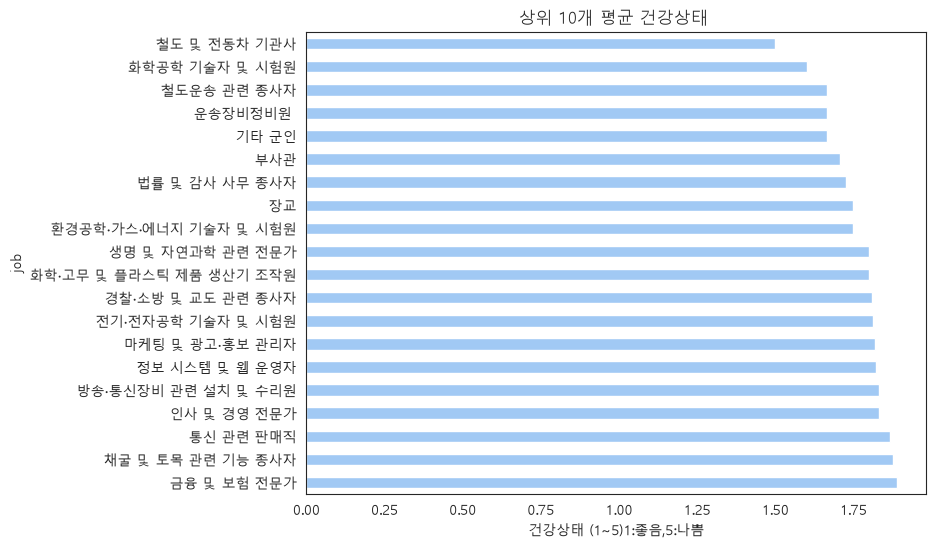

In [52]:
data_check = data.groupby('job')['health'].mean()
data_check = data_check.sort_values(ascending=False).tail(20)
plt.figure(figsize= (8,6))
data_check.plot(kind='barh')
plt.title("상위 10개 평균 건강상태 ")
plt.xlabel("건강상태 (1~5)1:좋음,5:나쁨")
plt.show()

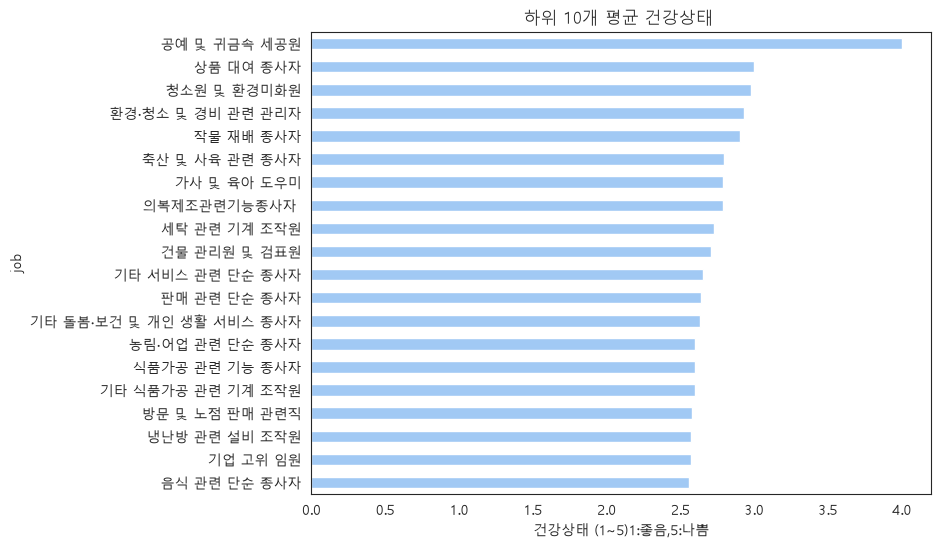

In [53]:
data_check = data.groupby('job')['health'].mean()
data_check = data_check.sort_values(ascending=False).head(20).sort_values()
plt.figure(figsize= (8,6))
data_check.plot(kind='barh')
plt.title("하위 10개 평균 건강상태 ")
plt.xlabel("건강상태 (1~5)1:좋음,5:나쁨")
plt.show()

In [54]:
data = data.assign(
    agetype = np.where(
        data['age'] < 30,'youth',   # 데이터 나이 30 미만 청년층
        np.where(
            data['age'] <60 ,'middle age','senior'  # 30~59 중장년층,60세 이상은 고령층
        )
    )
)
data

,health_checkup,health,job_code,birth,job,age,agetype
1,1.0,3.0,942.0,1948.0,건물 관리원 및 검표원,78,senior
3,1.0,3.0,855.0,1962.0,금속기계 부품 조립원,64,senior
4,0.0,3.0,314.0,1963.0,비서 및 사무 보조원,63,senior
7,1.0,3.0,941.0,1940.0,청소원 및 환경미화원,86,senior
8,1.0,4.0,151.0,1970.0,판매 및 운송 관리자,56,middle age
...,...,...,...,...,...,...,...
14906,1.0,2.0,151.0,1976.0,판매 및 운송 관리자,50,middle age
14907,0.0,2.0,312.0,1977.0,경영 관련 사무원,49,middle age
14910,1.0,2.0,222.0,1975.0,컴퓨터 시스템 및 소프트웨어 전문가,51,middle age
14911,1.0,2.0,313.0,1976.0,회계 및 경리 사무원,50,middle age


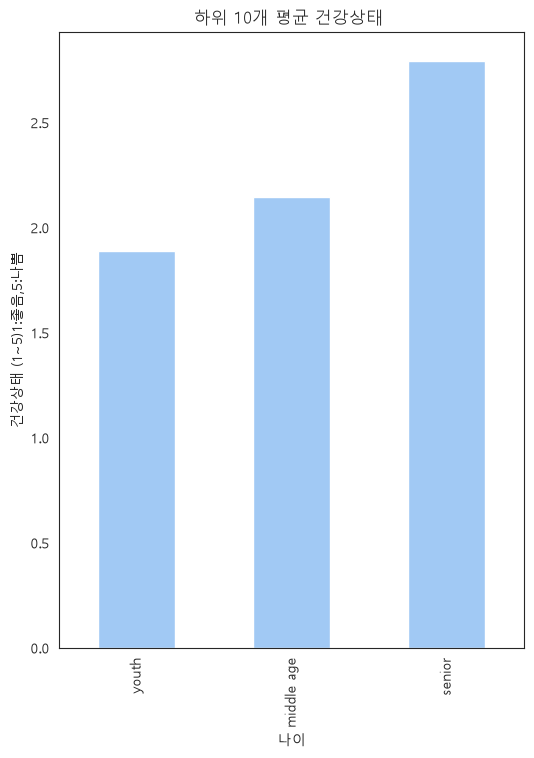

In [55]:
data_check = data.groupby('agetype')['health'].mean()
data_check = data_check.sort_values(ascending=False).head(20).sort_values()
plt.figure(figsize= (6,8))
data_check.plot(kind='bar')
plt.title("하위 10개 평균 건강상태 ")
plt.xlabel("나이")
plt.ylabel("건강상태 (1~5)1:좋음,5:나쁨")
plt.show()

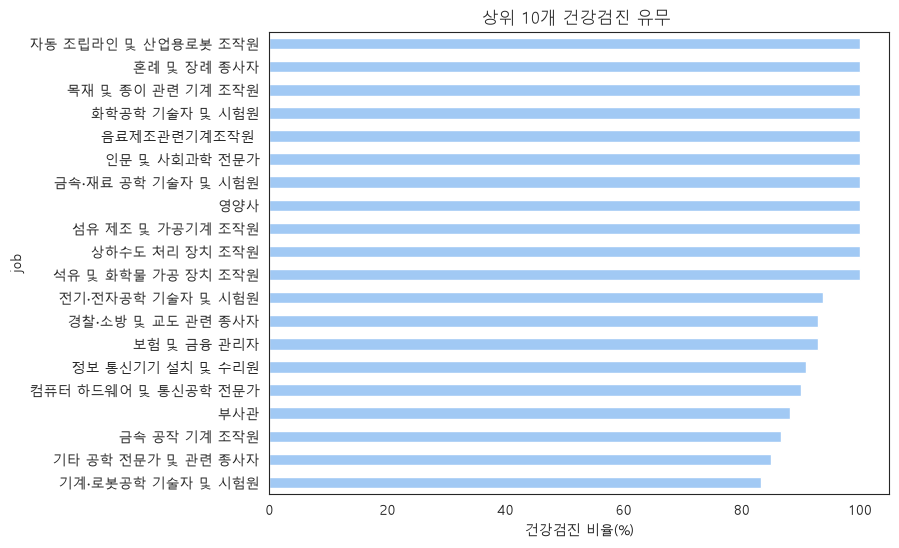

In [56]:

data_check = data.groupby('job')['health_checkup'].mean() *100
data_check = data_check.sort_values(ascending=False).head(20).sort_values()
plt.figure(figsize= (8,6))
data_check.plot(kind='barh')
plt.title("상위 10개 건강검진 유무 ")
plt.xlabel("건강검진 비율(%)")
plt.show()

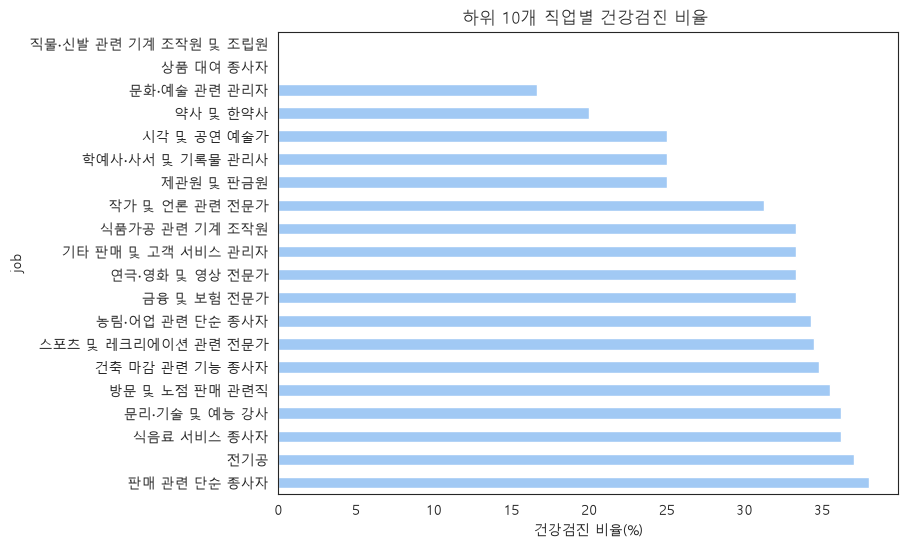

In [57]:
data_check = data.groupby('job')['health_checkup'].mean()*100
data_check = data_check.sort_values(ascending=False).tail(20)
plt.figure(figsize= (8,6))
data_check.plot(kind='barh')
plt.title("하위 10개 직업별 건강검진 비율 ")
plt.xlabel("건강검진 비율(%)")
plt.show()

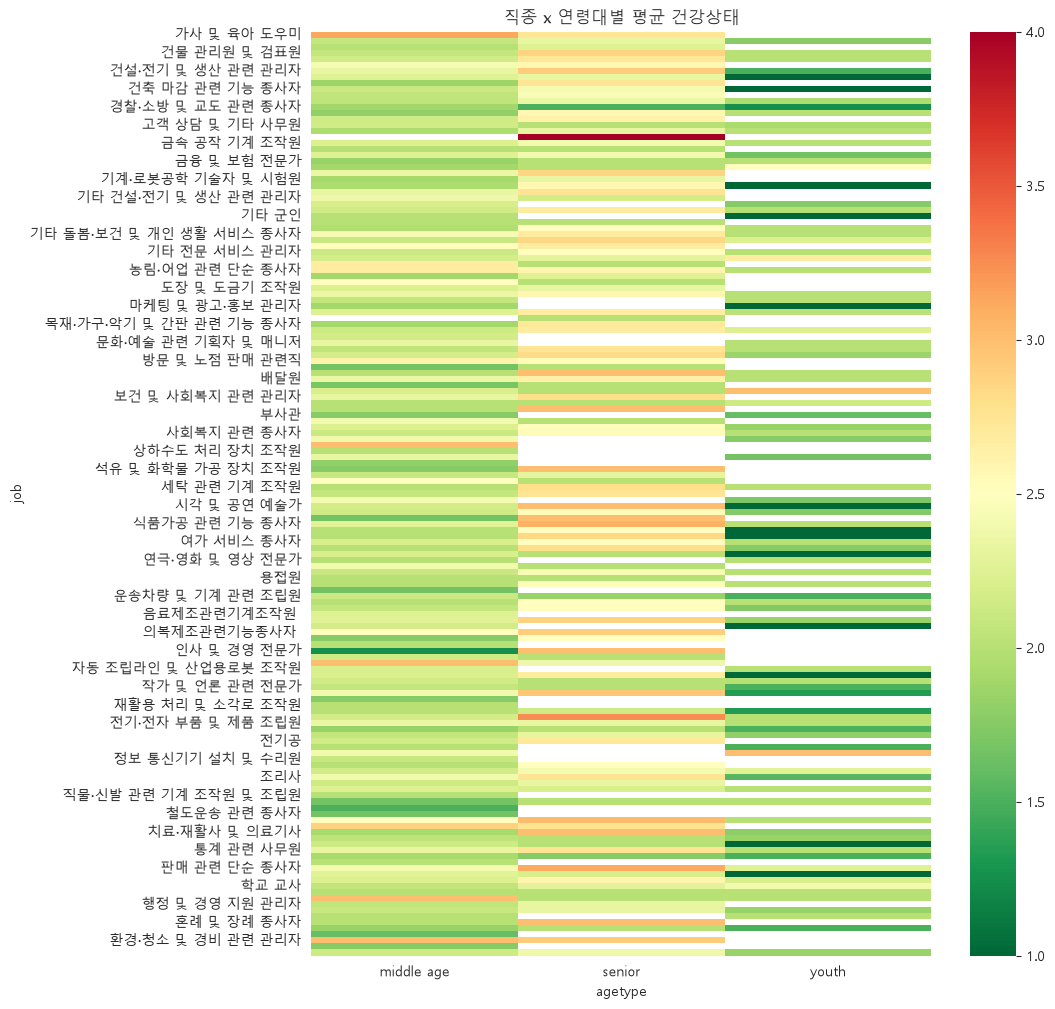

In [62]:
pivot = data.pivot_table(index='job', columns='agetype', values='health', aggfunc='mean')

plt.figure(figsize=(10, 12))
sns.heatmap(pivot, cmap='RdYlGn_r', annot=False)  # 값이 클수록(나쁠수록) 빨간색
plt.title('직종 x 연령대별 평균 건강상태')
plt.show()

In [156]:
myString="banana"	
pat	 = "ana"

answer = 0
a = ""
n = len(pat)
for i in reversed(myString): 
    a+=i
    # print(a)
    
    print(a[-n:])
    if a[-n:] == pat:
        answer+=1
        print(answer)

a
an
ana
1
nan
ana
2
nab


In [101]:
cnt

0

In [73]:
a [:-n]

['b', 'a', 'n']

In [ ]:
myString = "AAAAaaaab"
pat = "aa"
answer = ''
n = len(pat)
longest = None
for i in (myString): 
    answer+=i
    if answer[-n:] == pat:
        longest = answer
        print(longest)
    else:
        if longest is not None:
            longest = None
if longest is not None





AAAAaa
AAAAaaa
AAAAaaaa


In [199]:
answer

'AAAAaa'